# The Task description
A supervised learning, binary classification task on an image dataset.

# Important Necessary Libs

In [1]:
%pip install --upgrade pip setuptools wheel

%pip install \
numpy==1.26.4 \
scipy==1.11.4 \
matplotlib==3.8.4 \
seaborn==0.13.2 \
pandas==2.2.2 \
scikit-learn==1.5.1 \
opencv-python==4.10.0.84 \
tensorflow==2.16.1 \
keras==3.3.3 \
kagglehub \

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import scipy
import matplotlib
import seaborn as sns
import pandas as pd
import sklearn
import cv2
import kagglehub
import shutil
from pathlib import Path
import json

"""
requirements = {
    "numpy": ("1.24.0", np.__version__),
    "scipy": ("1.14.1", scipy.__version__),
    "matplotlib": ("3.9.2", matplotlib.__version__),
    "seaborn": ("0.12.0", sns.__version__),
    "pandas": ("2.2.3", pd.__version__),
    "scikit-learn": ("1.5.2", sklearn.__version__),
    "opencv-python": ("4.5.4", cv2.__version__),  # use prefix, not full wheel tag
}

for pkg, (expected, actual) in requirements.items():
    assert actual.startswith(expected), f"{pkg}: expected {expected}, got {actual}"

print("All checked versions match.")
"""

'\nrequirements = {\n    "numpy": ("1.24.0", np.__version__),\n    "scipy": ("1.14.1", scipy.__version__),\n    "matplotlib": ("3.9.2", matplotlib.__version__),\n    "seaborn": ("0.12.0", sns.__version__),\n    "pandas": ("2.2.3", pd.__version__),\n    "scikit-learn": ("1.5.2", sklearn.__version__),\n    "opencv-python": ("4.5.4", cv2.__version__),  # use prefix, not full wheel tag\n}\n\nfor pkg, (expected, actual) in requirements.items():\n    assert actual.startswith(expected), f"{pkg}: expected {expected}, got {actual}"\n\nprint("All checked versions match.")\n'

# Data Preprocessing

## Download Dataset Function

In [16]:
PROJECT_ROOT = Path.home() / "DS-Assign-2"

def ensure_pneumonia_dataset(
    dataset_name="paultimothymooney/chest-xray-pneumonia",
    target_dir=None
):
    if target_dir is None:
        target_path = PROJECT_ROOT / "data" / "chest_xray"
    else:
        target_path = Path(target_dir).expanduser().resolve()

    if target_path.exists():
        print(f"Dataset already exists at: {target_path}")
        return target_path

    print("Dataset not found. Downloading...")
    downloaded_path = Path(kagglehub.dataset_download(dataset_name))

    target_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.move(str(downloaded_path), str(target_path))

    print(f"Dataset stored at: {target_path}")
    return target_path

## Preproccess and Cache Data Function

In [18]:
# JSON schema for processed data storage for future use
json_schema = {
    "title": "Preprocessed Xray Dataset Index",
    "type": "object",
    "properties": {
        "samples": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "filename": {"type": "string"},
                    "split": {"type": "string", "enum": ["train", "val", "test"]},
                    "label": {"type": "integer", "enum": [0, 1]},
                    "array_file": {"type": "string"},
                    "image_size": {
                        "type": "array",
                        "items": {"type": "integer"},
                        "minItems": 2,
                        "maxItems": 2
                    }
                },
                "required": ["filename", "split", "label", "array_file", "image_size"],
                "additionalProperties": False
            }
        }
    },
    "required": ["samples"],
    "additionalProperties": False
}

IMG_SIZES = ((224, 224), (256, 256))

label_map = {
    "NORMAL": np.uint8(0),
    "PNEUMONIA": np.uint8(1)
}

def preprocess_and_cache_dataset(
    raw_base_dir="data/chest_xray/chest_xray",
    processed_base_dir="data/processed",
    img_sizes=IMG_SIZES
):
    raw_base = Path(raw_base_dir)
    processed_base = Path(processed_base_dir)
    index_file = processed_base / "dataset_index.json"

    samples = []

    for img_size in img_sizes:
        width, height = img_size
        size_name = f"{width}x{height}"
        arrays_base = processed_base / "arrays" / size_name

        # Create output folders per size and split
        for split in ["train", "val", "test"]:
            (arrays_base / split).mkdir(parents=True, exist_ok=True)

        for split in ["train", "val", "test"]:
            for class_name in ["NORMAL", "PNEUMONIA"]:
                class_dir = raw_base / split / class_name
                label = int(label_map[class_name])

                if not class_dir.exists():
                    print(f"Skipping missing directory: {class_dir}")
                    continue

                for file_path in class_dir.iterdir():
                    if not file_path.is_file():
                        continue

                    img = cv2.imread(str(file_path), cv2.IMREAD_GRAYSCALE)
                    if img is None:
                        print(f"Skipping unreadable file: {file_path}")
                        continue

                    # preprocess for this image size
                    img_resized = cv2.resize(img, img_size)
                    img_resized = img_resized.astype(np.float32) / 255.0
                    img_resized = np.expand_dims(img_resized, axis=-1)  # (H, W, 1)

                    # safer filename to avoid collisions
                    array_filename = f"{split}_{class_name}_{file_path.stem}.npy"
                    array_rel_path = Path("arrays") / size_name / split / array_filename
                    array_abs_path = processed_base / array_rel_path

                    np.save(array_abs_path, img_resized)

                    samples.append({
                        "filename": file_path.name,
                        "split": split,
                        "label": label,
                        "array_file": str(array_rel_path).replace("\\", "/"),
                        "image_size": [height, width]
                    })

    dataset_index = {"samples": samples}

    processed_base.mkdir(parents=True, exist_ok=True)
    with open(index_file, "w", encoding="utf-8") as f:
        json.dump(dataset_index, f, indent=2)

    print(f"Saved index to: {index_file}")
    print(f"Saved {len(samples)} processed samples across {len(img_sizes)} image sizes.")
    return dataset_index

## Load Data into Memory Function

In [19]:
def load_cached_splits(
    processed_base_dir="data/processed",
    img_size=(224, 224),
    return_filenames=False
):
    processed_base = Path(processed_base_dir)
    index_file = processed_base / "dataset_index.json"

    if not index_file.exists():
        raise FileNotFoundError(f"Index file not found: {index_file}")

    with open(index_file, "r", encoding="utf-8") as f:
        dataset_index = json.load(f)

    target_size = list(img_size)

    X_train, y_train, train_files = [], [], []
    X_val, y_val, val_files = [], [], []
    X_test, y_test, test_files = [], [], []

    for sample in dataset_index["samples"]:
        if sample["image_size"] != target_size:
            continue

        array_path = processed_base / sample["array_file"]
        if not array_path.exists():
            print(f"Skipping missing array file: {array_path}")
            continue

        img = np.load(array_path)
        label = np.uint8(sample["label"])
        filename = sample["filename"]
        split = sample["split"]

        if split == "train":
            X_train.append(img)
            y_train.append(label)
            train_files.append(filename)
        elif split == "val":
            X_val.append(img)
            y_val.append(label)
            val_files.append(filename)
        elif split == "test":
            X_test.append(img)
            y_test.append(label)
            test_files.append(filename)

    X_train = np.array(X_train, dtype=np.float32)
    y_train = np.array(y_train, dtype=np.uint8)

    X_val = np.array(X_val, dtype=np.float32)
    y_val = np.array(y_val, dtype=np.uint8)

    X_test = np.array(X_test, dtype=np.float32)
    y_test = np.array(y_test, dtype=np.uint8)

    if return_filenames:
        return (
            X_train, y_train, train_files,
            X_val, y_val, val_files,
            X_test, y_test, test_files
        )

    return X_train, y_train, X_val, y_val, X_test, y_test

# Main Data Functions Run

In [20]:
def prepare_and_load_pneumonia_data(
    dataset_name="paultimothymooney/chest-xray-pneumonia",
    raw_target_dir=None,
    processed_base_dir=None,
    img_size=(224, 224),
    img_sizes=IMG_SIZES,
    return_filenames=False
):
    if raw_target_dir is None:
        raw_target_dir = PROJECT_ROOT / "data" / "chest_xray"
    else:
        raw_target_dir = Path(raw_target_dir).expanduser().resolve()

    if processed_base_dir is None:
        processed_base_dir = PROJECT_ROOT / "data" / "processed"
    else:
        processed_base_dir = Path(processed_base_dir).expanduser().resolve()

    raw_dataset_path = ensure_pneumonia_dataset(
        dataset_name=dataset_name,
        target_dir=raw_target_dir
    )

    raw_base_dir = Path(raw_dataset_path) / "chest_xray"
    processed_base = Path(processed_base_dir)
    index_file = processed_base / "dataset_index.json"

    needs_preprocessing = True

    if index_file.exists():
        try:
            with open(index_file, "r", encoding="utf-8") as f:
                dataset_index = json.load(f)

            samples = dataset_index.get("samples", [])

            raw_count = 0
            for split in ["train", "val", "test"]:
                for class_name in ["NORMAL", "PNEUMONIA"]:
                    class_dir = raw_base_dir / split / class_name
                    if class_dir.exists():
                        raw_count += sum(1 for p in class_dir.iterdir() if p.is_file())

            expected_count = raw_count * len(img_sizes)
            count_ok = len(samples) == expected_count
            size_ok = any(sample["image_size"] == [img_size[1], img_size[0]] for sample in samples)

            files_ok = True
            for sample in samples:
                array_path = processed_base / sample["array_file"]
                if not array_path.exists():
                    files_ok = False
                    break

            needs_preprocessing = not (count_ok and size_ok and files_ok)

        except Exception as e:
            print(f"Processed cache check failed: {e}")
            needs_preprocessing = True

    if needs_preprocessing:
        print("Processing and caching dataset...")
        preprocess_and_cache_dataset(
            raw_base_dir=str(raw_base_dir),
            processed_base_dir=str(processed_base),
            img_sizes=img_sizes
        )
    else:
        print("Processed cache already valid. Skipping preprocessing.")

    return load_cached_splits(
        processed_base_dir=str(processed_base),
        img_size=img_size,
        return_filenames=return_filenames
    )

In [21]:
# There are two possible 
X_train, y_train, X_val, y_val, X_test, y_test = prepare_and_load_pneumonia_data(
    img_size=(224, 224)
)

Dataset not found. Downloading...
Dataset stored at: /Users/jakubkorus/DS-Assign-2/data/chest_xray
Processing and caching dataset...
Saved index to: /Users/jakubkorus/DS-Assign-2/data/processed/dataset_index.json
Saved 11712 processed samples across 2 image sizes.


## Sanity Check Data

In [77]:
# Return something (Non-empty)

#assert len()

# Row and image eqaul size checking
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]
assert X_val.shape[0] == y_val.shape[0]

# What other sanity checks??


## Exploratory Data Analysis

Explore the dataset to understand the input features (images), classes (normal vs.
pneumonia), and distribution of the data.
- Visualize sample images for both classes, along with their labels.

### Fold distributions and total

In [75]:
def distribution_calculation(dataset: np.ndarray[np.uint8]) -> dict:

    unique, counts = np.unique(dataset, return_counts=True)
    distribution_dict = {unique[i]: counts[i] for i in range(len(unique))}

    return distribution_dict

# class distribution total
y = np.concatenate([y_train, y_test, y_val])


datasets = {
    "TOTAL": y,
    "TRAIN": y_train,
    "TEST": y_test,
    "VAL": y_val
}

for name, labels in datasets.items():
    distribution = distribution_calculation(labels)
    total = len(labels)

    print(f"----- {name} CLASS DISTRIBUTION -----")

    for cls, count in distribution.items():
        percentage = (count / total) * 100
        print(f"class {cls}: {count} ({percentage:.2f}%)")

    print()


----- TOTAL CLASS DISTRIBUTION -----
class 0: 1583 (27.03%)
class 1: 4273 (72.97%)

----- TRAIN CLASS DISTRIBUTION -----
class 0: 1341 (25.71%)
class 1: 3875 (74.29%)

----- TEST CLASS DISTRIBUTION -----
class 0: 234 (37.50%)
class 1: 390 (62.50%)

----- VAL CLASS DISTRIBUTION -----
class 0: 8 (50.00%)
class 1: 8 (50.00%)



### Pixel intensity distributions per label

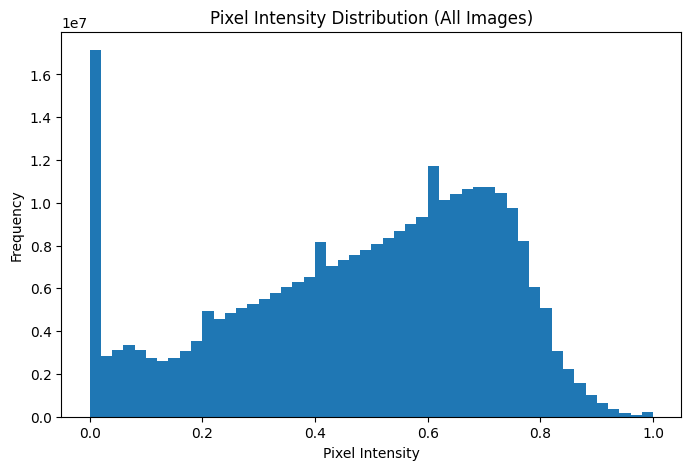

In [109]:
# flatten all pixels
pixels = X.flatten()

plt.figure(figsize=(8,5))
plt.hist(pixels, bins=50)

plt.title("Pixel Intensity Distribution (All Images)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

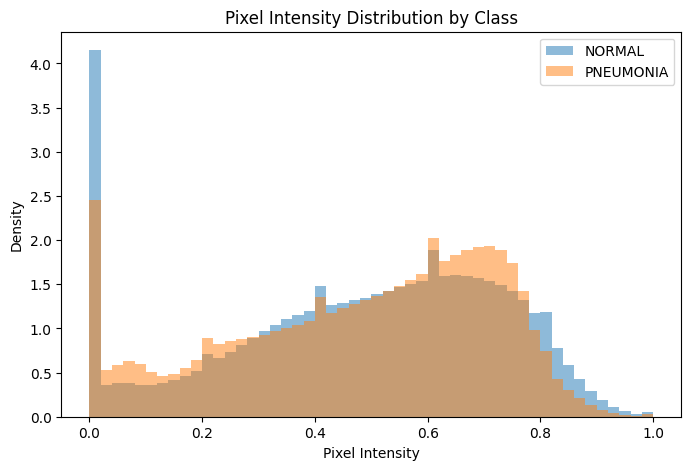

In [110]:
normal_pixels = X[y == 0].flatten()
pneumonia_pixels = X[y == 1].flatten()

plt.figure(figsize=(8,5))

plt.hist(normal_pixels, bins=50, alpha=0.5, label="NORMAL", density=True)
plt.hist(pneumonia_pixels, bins=50, alpha=0.5, label="PNEUMONIA", density=True)

plt.title("Pixel Intensity Distribution by Class")
plt.xlabel("Pixel Intensity")
plt.ylabel("Density")
plt.legend()

plt.show()

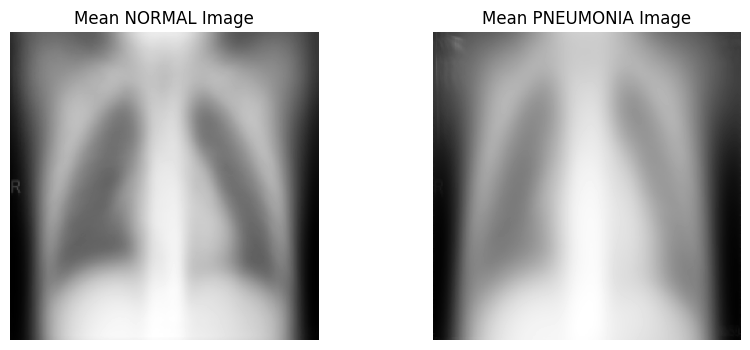

In [111]:
import numpy as np

mean_normal = X[y == 0].mean(axis=0)
mean_pneumonia = X[y == 1].mean(axis=0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(mean_normal.squeeze(), cmap="gray")
plt.title("Mean NORMAL Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mean_pneumonia.squeeze(), cmap="gray")
plt.title("Mean PNEUMONIA Image")
plt.axis("off")

plt.show()

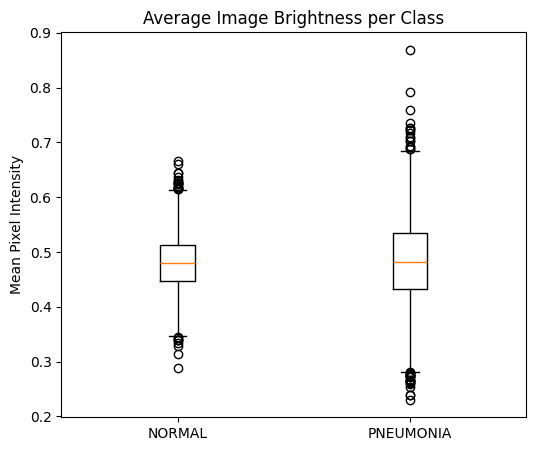

In [112]:
mean_intensity = X.mean(axis=(1,2,3))

plt.figure(figsize=(6,5))

plt.boxplot(
    [mean_intensity[y==0], mean_intensity[y==1]],
    labels=["NORMAL", "PNEUMONIA"]
)

plt.title("Average Image Brightness per Class")
plt.ylabel("Mean Pixel Intensity")

plt.show()

### t-SNE plot of combined dataset

In [85]:
X = np.concatenate([X_train, X_test, X_val])
X_flat = X.reshape(X.shape[0], -1)
print(X_flat.shape)

(5856, 50176)


In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# flatten images into feature vectors
X_vectors = X.reshape(X.shape[0], -1)

# reduce dim 
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_vectors)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca)


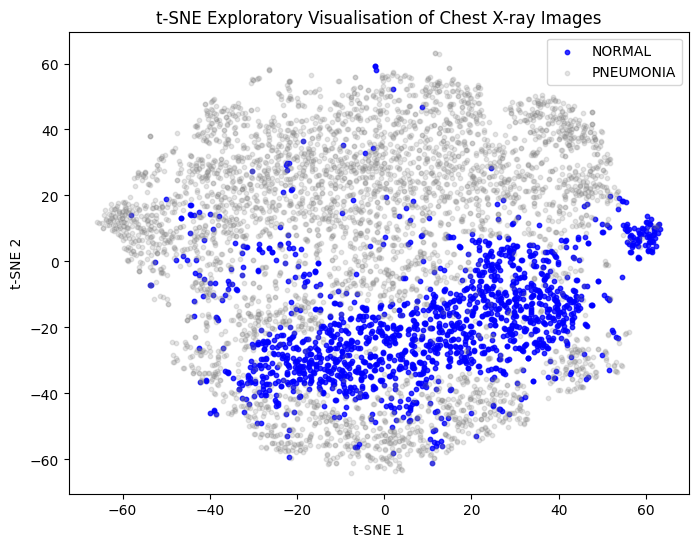

In [104]:
# plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[y == 0, 0],
    X_tsne[y == 0, 1],
    label="NORMAL",
    alpha=0.8,
    s=10,
    color="blue"
)

plt.scatter(
    X_tsne[y == 1, 0],
    X_tsne[y == 1, 1],
    label="PNEUMONIA",
    alpha=0.2,
    s=10,
    color="grey"
)

plt.title("t-SNE Exploratory Visualisation of Chest X-ray Images")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()

plt.show()

# Baseline

CNN Baseline

- Use the example CNN architecture provided in the Kaggle code as a base. Understand the
role of key components like convolutional layers, pooling layers, and fully connected layers.
- Train the model on the training dataset.
- Track and report model performance metrics (accuracy, loss) during training and on the test
dataset.

# Performance Eval

After training, evaluate the model on the test set.
- Present the confusion matrix, precision, recall, and F1 score for the baseline model.

In [ ]:
## confusion matrix


## Precision


## Recall


# F1-scores

# Hyperparameter Optimisation and Alternative Model.

## HPO

## Alternative Model

# Results generation